# 02 - Power and Energy Visualization

This notebook creates visual representations of the power profile and energy consumption across the Archer Midnight's mission. The visualizations highlight the fundamental trade-off in eVTOL design:

- **Hover segments** have high power but short duration
- **Cruise** has moderate power but long duration

Understanding where the energy goes is essential for identifying which design parameters have the most affect.

In [ ]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft
import matplotlib.pyplot as plt

aircraft = Aircraft('../Archer_Midnight.json')

## Electric Power Profile

The step plot below shows electric power demand over time for the entire primary mission:

- **High peaks** at hover climb and hover descend.
- **Elevated plateau** during transition phases (combined hover-assist + aerodynamic drag)
- **Moderate steady-state** during cruise (drag-based: $P = D \cdot v / (\eta_{rotor} \cdot \eta_{epu})$)
- **Low power** during taxi (horizontal acceleration only, no aerodynamic drag)

The ratio of hover to cruise power, with an overtorque safety factor applied, determines how oversized the motors and power electronics must be relative to the cruise operating point.

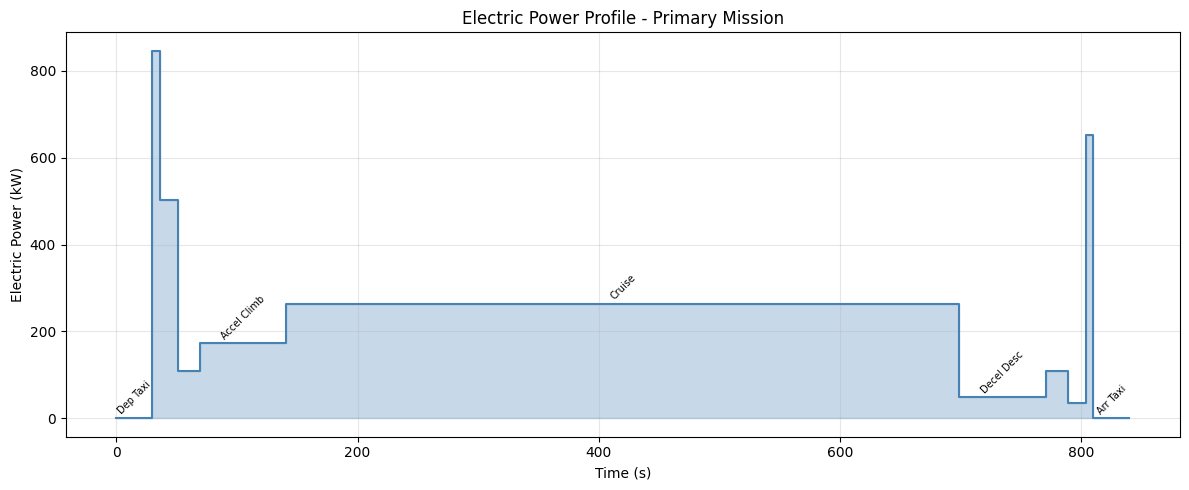

In [2]:
segments = [
    ('Dep Taxi',    aircraft.depart_taxi_avg_electric_power_kw,    aircraft.mission.depart_taxi_s),
    ('Hvr Climb',   aircraft.hover_climb_avg_electric_power_kw,    aircraft.mission.hover_climb_s),
    ('Trans Climb', aircraft.trans_climb_avg_electric_power_kw,    aircraft.mission.trans_climb_s),
    ('Dep Proc',    aircraft.depart_proc_avg_electric_power_kw,   aircraft.mission.depart_proc_s),
    ('Accel Climb', aircraft.accel_climb_avg_electric_power_kw,    aircraft.mission.accel_climb_s),
    ('Cruise',      aircraft.cruise_avg_electric_power_kw,         aircraft.mission.cruise_s),
    ('Decel Desc',  aircraft.decel_descend_avg_electric_power_kw,  aircraft.mission.decel_descend_s),
    ('Arr Proc',    aircraft.arrive_proc_avg_electric_power_kw,   aircraft.mission.arrive_proc_s),
    ('Trans Desc',  aircraft.trans_descend_avg_electric_power_kw,  aircraft.mission.trans_descend_s),
    ('Hvr Desc',    aircraft.hover_descend_avg_electric_power_kw,  aircraft.mission.hover_descend_s),
    ('Arr Taxi',    aircraft.arrive_taxi_avg_electric_power_kw,    aircraft.mission.arrive_taxi_s),
]

# Build step profile
times = []
powers = []
t = 0.0
for name, power, duration in segments:
    times.extend([t, t + duration])
    powers.extend([power, power])
    t += duration

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(times, powers, alpha=0.3, color='steelblue')
ax.plot(times, powers, color='steelblue', linewidth=1.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Electric Power (kW)')
ax.set_title('Electric Power Profile - Primary Mission')
ax.grid(True, alpha=0.3)

# Add segment labels
t = 0.0
for name, power, duration in segments:
    if duration > 20:  # only label segments wide enough
        ax.text(t + duration/2, power + 5, name, ha='center', va='bottom', fontsize=7, rotation=45)
    t += duration

plt.tight_layout()
plt.show()

## Energy Consumption by Segment

Energy tells a different story than power. The cruise segment (highlighted in red) typically consumes the most energy despite its lower power, because it occupies the majority of the mission time.

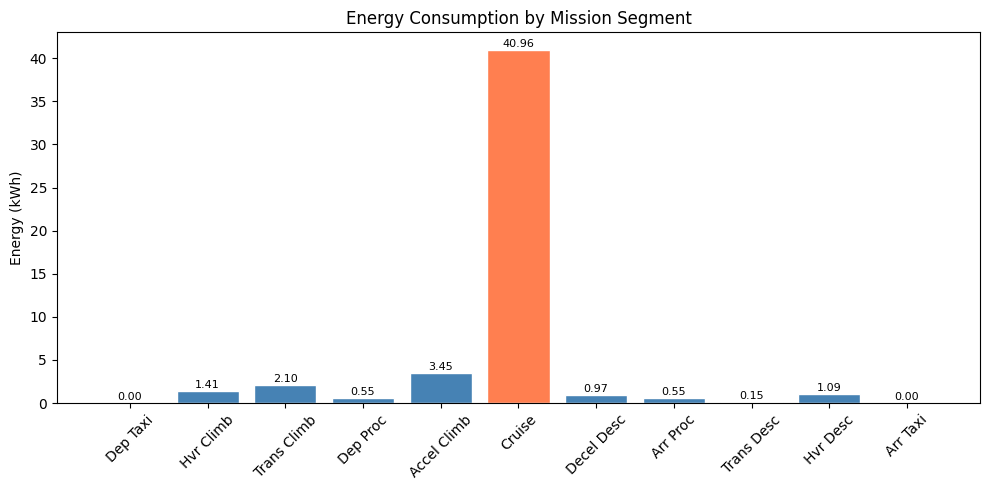

In [3]:
energy_data = [
    ('Dep Taxi',      aircraft.depart_taxi_energy_kw_hr),
    ('Hvr Climb',     aircraft.hover_climb_energy_kw_hr),
    ('Trans Climb',   aircraft.trans_climb_energy_kw_hr),
    ('Dep Proc',      aircraft.depart_proc_energy_kw_hr),
    ('Accel Climb',   aircraft.accel_climb_energy_kw_hr),
    ('Cruise',        aircraft.cruise_energy_kw_hr),
    ('Decel Desc',    aircraft.decel_descend_energy_kw_hr),
    ('Arr Proc',      aircraft.arrive_proc_energy_kw_hr),
    ('Trans Desc',    aircraft.trans_descend_energy_kw_hr),
    ('Hvr Desc',      aircraft.hover_descend_energy_kw_hr),
    ('Arr Taxi',      aircraft.arrive_taxi_energy_kw_hr),
]

names = [n for n, _ in energy_data]
energies = [e for _, e in energy_data]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['coral' if e == max(energies) else 'steelblue' for e in energies]
bars = ax.bar(names, energies, color=colors, edgecolor='white')
ax.set_ylabel('Energy (kWh)')
ax.set_title('Energy Consumption by Mission Segment')
ax.tick_params(axis='x', rotation=45)
for bar, energy in zip(bars, energies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{energy:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## Cumulative Energy

The cumulative energy plot tracks how the battery budget is consumed throughout the mission.
- The **final value** is the total primary mission energy, which (combined with reserve energy) determines battery mass

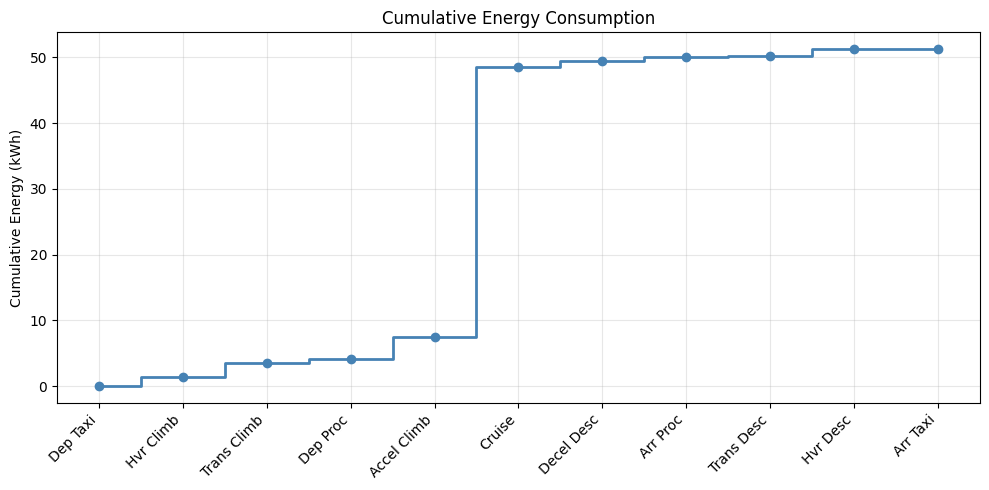

In [4]:
cumulative = []
running = 0.0
for _, e in energy_data:
    running += e
    cumulative.append(running)

fig, ax = plt.subplots(figsize=(10, 5))
ax.step(range(len(names)), cumulative, where='mid', color='steelblue', linewidth=2)
ax.scatter(range(len(names)), cumulative, color='steelblue', zorder=5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel('Cumulative Energy (kWh)')
ax.set_title('Cumulative Energy Consumption')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Primary vs Reserve Energy

The battery must carry enough energy for both missions. The chart below shows how the total energy budget is split. The reserve mission is shorter but still adds a significant energy requirement, which directly increases battery mass and MTOW.

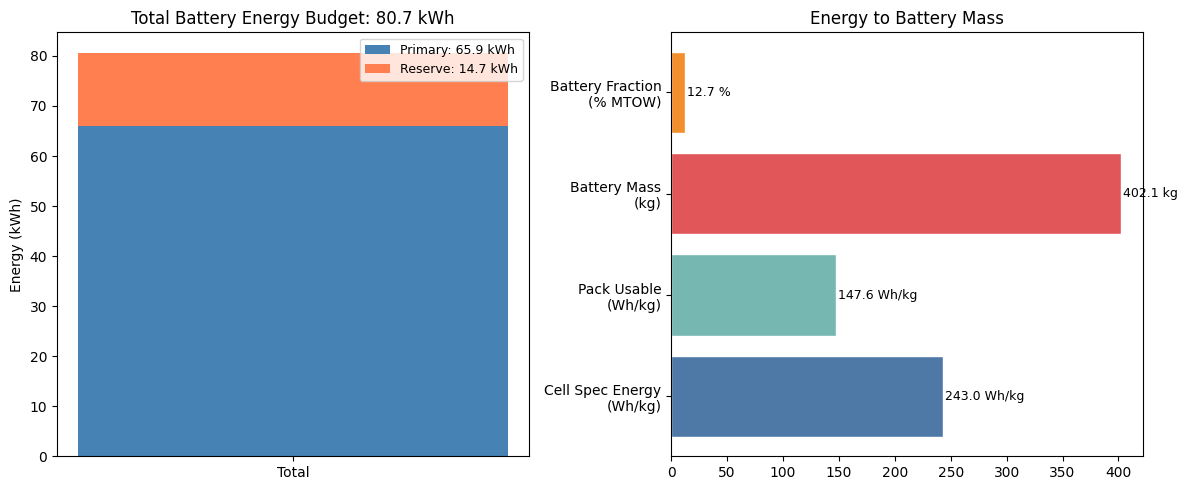

In [5]:
primary_energy = aircraft.total_mission_energy_kw_hr
reserve_energy = aircraft.total_reserve_mission_energy_kw_hr
total_energy = primary_energy + reserve_energy

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stacked bar
axes[0].bar('Total', primary_energy, label=f'Primary: {primary_energy:.1f} kWh', color='steelblue')
axes[0].bar('Total', reserve_energy, bottom=primary_energy,
            label=f'Reserve: {reserve_energy:.1f} kWh', color='coral')
axes[0].set_ylabel('Energy (kWh)')
axes[0].set_title(f'Total Battery Energy Budget: {total_energy:.1f} kWh')
axes[0].legend(fontsize=9)

# Energy to battery mass connection
usable_spec_energy = (aircraft.power.batt_int_factor *
                      (1 - aircraft.power.batt_inaccessible_energy_frac) *
                      aircraft.power.batt_eol_capacity *
                      aircraft.power.batt_spec_energy_w_h_p_kg)

axes[1].barh(['Cell Spec Energy\n(Wh/kg)', 'Pack Usable\n(Wh/kg)', 'Battery Mass\n(kg)', 'Battery Fraction\n(% MTOW)'],
             [aircraft.power.batt_spec_energy_w_h_p_kg, usable_spec_energy,
              aircraft.battery_mass_kg, 100 * aircraft.battery_mass_kg / aircraft.max_takeoff_mass_kg],
             color=['#4e79a7', '#76b7b2', '#e15759', '#f28e2b'], edgecolor='white')
for i, (val, label) in enumerate(zip(
    [aircraft.power.batt_spec_energy_w_h_p_kg, usable_spec_energy,
     aircraft.battery_mass_kg, 100 * aircraft.battery_mass_kg / aircraft.max_takeoff_mass_kg],
    ['Wh/kg', 'Wh/kg', 'kg', '%'])):
    axes[1].text(val + 2, i, f'{val:.1f} {label}', va='center', fontsize=9)
axes[1].set_title('Energy to Battery Mass')

plt.tight_layout()
plt.show()

## Summary

Key insights from the power and energy visualizations:

- **Power profile shape**: The characteristic eVTOL power profile has high peaks at hover, elevated transition power, and a moderate cruise steady-state. The motors and inverters must be sized to hover, and hover OEI conditions.
- **Energy is dominated by cruise**: Despite lower instantaneous power, cruise consumes the most energy because $E = P \cdot t$ and cruise duration is 60-80% of the mission. 
- **Reserve adds significant battery mass**: The reserve mission energy requirement increases total battery mass, which feeds back into MTOW through the sizing loop.
- **Battery derating matters**: Cell-level specific energy is significantly reduced at the pack level by integration factor, max depth of discharge, inaccessible energy fraction, and end of life capacity fade.

**Next:** Move on to [06 - Aerodynamics] to explore the drag buildup.